In [ ]:
import numpy as np

def writeHOHxyz(bond_length, min_angle, max_angle, angle_inc):
    # the angle given is HOH, so that is why we need to divide by 2 in the function
    for deg in np.arange(min_angle, max_angle+1, angle_inc):
        x = np.sin(np.deg2rad(deg / 2.0)) * bond_length
        y = np.cos(np.deg2rad(deg / 2.0)) * bond_length
        xyzname = "HOH-bl" + str(bond_length) + "-deg-" + str(deg).zfill(3) + ".xyz"
        # print(xyzname)
        with open(xyzname, "w") as f:
            f.write("3\n")
            f.write(f"HOH angle {deg}\n") #we need the comment line for ORCA to parse
            f.write("O 0.000000 0.000000 0.000000\n")
            f.write(f"H {-x:.6f} {y:.6f} 0.000000\n")
            f.write(f"H {x:.6f} {y:.6f} 0.000000\n")
        f.close()

writeHOHxyz(0.951, 90, 180, 10)


Here I differ from the tutorial because I can't run terachem on a laptop, without access
to a compute cluster. 
Since the molecule is small, I decided to continue using ORCA

In [8]:
def write_orca_input(xyzfile):
    infile = xyzfile.replace(".xyz", ".in")

    with open(infile, "w") as f:
        f.write("! B3LYP 6-31G* SP\n\n")
        f.write(f"* xyzfile 0 1 {xyzfile}\n")
        
#SP = single point energy. not doing an optimization - we want the energy at that particular angle

In [9]:
import subprocess
import glob

for xyzfile in glob.glob("*.xyz"):
    write_orca_input(xyzfile)

for infile in glob.glob("*.in"):
    outfile = infile.replace(".in", ".out")

    subprocess.run(
        f"orca {infile} > {outfile}",
        shell=True
    )

/bin/sh: line 1: 10232 Segmentation fault: 11  orca water.in > water.out


In [ ]:
import re

energies = []

for out in sorted(glob.glob("*.out")):
    with open(out) as f:
        text = f.read()

    m = re.search(
        r"FINAL SINGLE POINT ENERGY\s+(-?\d+\.\d+)",
        text
    )
    #highk chatted the past 3 lines cuz idk regex son

    if m:
        energy = float(m.group(1))
        energies.append(energy)

In [13]:
energies = np.array(energies)
rel_energy = energies - np.min(energies)
rel_energy *= 627.509 #convert to kcal/mol
rel_energy

array([ 3.52663702,  0.        ,  0.1202055 ,  3.25992079,  8.67869636,
       15.48003288, 22.60470574, 28.85655593, 33.18173816, 34.72705656])

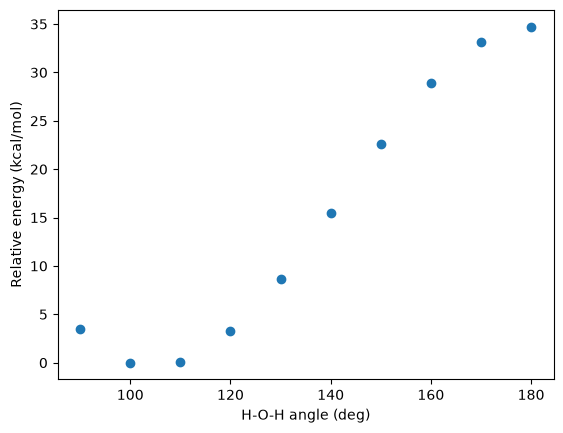

In [14]:
import matplotlib.pyplot as plt
angles = [90,100,110,120,130,140,150,160,170,180]
angles = np.array(angles)
plt.scatter(angles, rel_energy)
plt.xlabel("H-O-H angle (deg)")
plt.ylabel("Relative energy (kcal/mol)")
plt.show()